# NEOMOD3 k=150 geometric TEST2 — new VDP vs legacy VDP vs digest2

Reads **frozen scored artifacts only**. No simulation, no map build, no rescoring.

## What this evaluation is, and is not

TEST2 is deliberately **fresh independent NEOMOD3 NEOs + frozen REUSED prior-TEST S3M non-NEOs**.
The strict fresh-non-NEO gate **FAILED** and that finding stands: the previously inspected TEST had
already consumed every eligible TEST-split S3M parent.

- **The strongest result here is the paired classifier comparison** on identical rows. All three
  classifiers see the same contaminant rows, so differences between them are internally valid.
- Absolute contamination, precision and FPR are **not** a fresh out-of-sample estimate, because the
  contaminant sample is not independent of that earlier look.
- No tuning was performed on TEST2. No operating threshold is selected from it. Any best-F1 style
  number would be descriptive only.

## Coverage: two different quantities

| quantity | value |
|---|---|
| NEO-cell availability | 99.33% raw |
| **four-density VDP scoring coverage** | **43.96% raw / 45.06% weighted** |

A valid new-VDP probability requires **all four** population densities to be present and finite.
Partial-denominator rows are NaN with an explicit reason and are never used as a fallback; missing
TNO/Trojan densities are never converted to zero.

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

W = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
T2 = W/"outputs"/"test2_geometric"
val  = json.load(open(T2/"TEST2_SCORED_VALIDATION.json"))
seal = json.load(open(T2/"TEST2_SEAL.json"))
scor = json.load(open(T2/"SCORING_SEAL.json"))
leak = json.load(open(T2/"TEST2_LEAKAGE_AUDIT.json"))
cova = json.load(open(T2/"TEST2_COVERAGE_AUDIT.json"))
df   = pd.read_parquet(T2/"TEST2_SCORED.parquet")
POPS = ("NEO","MBA","TNO","Trojans")
print(f"TEST2_SCORED rows {len(df):,}   integrity ALL_PASS={val['ALL_PASS']}")
print(f"map root      : {scor['map_root']}")
print(f"map seal      : {scor['map_build_seal_sha256'][:32]}...")
print(f"digest2       : {scor['environment']['digest2_version_string']}")

TEST2_SCORED rows 688,688   integrity ALL_PASS=True
map root      : /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_mag025_k150_maps_v2
map seal      : a010bb1bf2e421a3258ff007f7bc4034...
digest2       : Digest2 version 0.19 -- Released August 16, 2017 -- Compiled May 28 2026


## 1. Provenance and integrity

In [2]:
print("DESIGN :", seal["design"])
print("GATE   :", seal["fresh_nonneo_gate"])
print("LIMIT  :", seal["limitation"])
print()
print("k by population        :", scor["k_by_population"])
print("gaussian smoothing     :", scor["frozen_config"]["gaussian_smoothing"])
print("support masking        :", scor["frozen_config"]["support_masking"])
print("grid                   :", scor["frozen_config"]["grid_lim"], "@", scor["frozen_config"]["grid_step"])
print("magnitude bins         :", scor["frozen_config"]["bin_scheme"]["n_bins"], "x",
      scor["frozen_config"]["bin_scheme"]["step"], scor["frozen_config"]["bin_scheme"]["semantics"])
print("NEO effective_factor   :", scor["frozen_config"]["neo_effective_factor"])
print()
fails = [c for c in val["checks"] if not c["pass"]]
print(f"integrity checks: {len(val['checks'])} run, {len(fails)} failed")
assert not fails, fails
print("\nleakage audit: GEN 0 / CAL 0 / prior-TEST",
      sum(r['overlap_prior_TEST'] for r in leak['overlap_table']),
      "-> fresh-non-NEO gate", "PASSED" if leak['fresh_test2_gate_passed'] else "FAILED (intentional reuse)")

DESIGN : fresh independent TEST2 NEOs + frozen REUSED prior-TEST S3M non-NEOs
GATE   : FAILED (see TEST2_LEAKAGE_AUDIT.json) — reuse is intentional
LIMIT  : non-NEO parents were used in the previously inspected TEST, so absolute contamination/precision/FPR are not independent of that look; the paired classifier comparison on identical rows is the valid quantity

k by population        : {'NEO': 150, 'MBA': 10, 'TNO': 10, 'Trojans': 10}
gaussian smoothing     : False
support masking        : False
grid                   : [-5.0, 5.0] @ 0.01
magnitude bins         : 44 x 0.25 half-open [lo, lo+step)
NEO effective_factor   : 64.725384

integrity checks: 31 run, 0 failed

leakage audit: GEN 0 / CAL 0 / prior-TEST 636801 -> fresh-non-NEO gate FAILED (intentional reuse)


## 2. Population counts and physical weights

NEO is oversampled ~10x its physical expectation and carries `w_phys` so that weighted contamination
and precision are unchanged; only NEO Monte-Carlo noise falls.

In [3]:
t = df.groupby("population").agg(rows=("tracklet_uid","size"), weight=("w_phys","sum")).reset_index()
t["w_per_row"] = t.weight/t.rows
print(t.to_string(index=False))
n = seal["neo"]
print(f"\nexpected physical NEO {n['expected_physical_neo']:.4f} / sampled {n['n_sampled']:,}"
      f" -> w_phys {n['w_phys']:.10f}  (not exactly 0.1)")
print(f"NEO draws {n['n_draws']:,} seeds {n['seed_base']:,}+0..{n['n_shards']-1}")

population   rows       weight  w_per_row
       MBA 614710 614710.00000   1.000000
       NEO  49887   4988.67353   0.099999
       TNO   7575   7575.00000   1.000000
   Trojans  16516  16516.00000   1.000000

expected physical NEO 4988.6735 / sampled 49,887 -> w_phys 0.0999994694  (not exactly 0.1)
NEO draws 300,000,000 seeds 777,000,000+0..149


## 3. Coverage and abstention over all 688,688 rows (View A)

raw valid fraction by classifier:
classifier  digest2  legacy_vdp  new_vdp
population                              
MBA          100.00      100.00    43.71
NEO          100.00       94.81    28.12
TNO           99.09      100.00    51.88
Trojans      100.00      100.00    97.46

NEO-cell availability      : 99.33%
four-density coverage raw  : 43.96%
four-density coverage wtd  : 45.06%


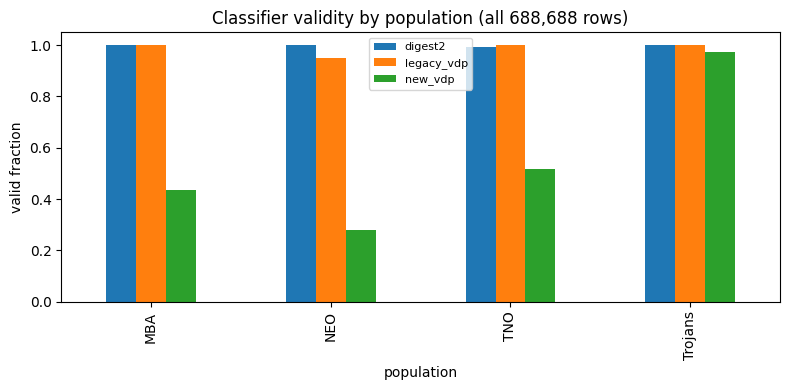

In [4]:
cov = pd.DataFrame(val["view_a_coverage"])
piv = cov.pivot(index="population", columns="classifier", values="raw")
print("raw valid fraction by classifier:"); print((100*piv).round(2).to_string())
print(f"\nNEO-cell availability      : {100*cova['neo_cell_availability_raw']:.2f}%")
print(f"four-density coverage raw  : {100*cova['four_density_coverage_raw']:.2f}%")
print(f"four-density coverage wtd  : {100*cova['four_density_coverage_weighted']:.2f}%")
fig,ax=plt.subplots(figsize=(8,4))
piv.plot(kind="bar",ax=ax); ax.set_ylabel("valid fraction"); ax.set_ylim(0,1.05)
ax.set_title("Classifier validity by population (all 688,688 rows)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [5]:
rs = pd.DataFrame(val["new_vdp_reason_counts"])
print("new-VDP reason codes by population (top per population):")
for p in POPS:
    g = rs[rs.population==p].head(4)
    print(f"  {p}:"); print(g[["new_vdp_reason","n"]].to_string(index=False, header=False))

new-VDP reason codes by population (top per population):
  NEO:
    missing_population_density:Trojans 25134
                                    ok 14027
missing_population_density:TNO,Trojans  8025
        missing_population_density:TNO  1979
  MBA:
    missing_population_density:Trojans 302467
                                    ok 268682
missing_population_density:TNO,Trojans  28320
        missing_population_density:TNO  10867
  TNO:
                                    ok 3930
    missing_population_density:Trojans 3605
missing_population_density:TNO,Trojans   20
        missing_population_density:TNO   19
  Trojans:
                                        ok 16096
            missing_population_density:TNO   390
missing_population_density:NEO,TNO,Trojans    21
    missing_population_density:TNO,Trojans     7


### Availability is geometrically selected, and worst for NEO

Four-density availability is **~28% for NEO** because many narrow TNO/Trojan 0.25-mag cells are
unavailable (`insufficient_support` at k=10 in a 0.25-mag slice, or `no_split_fraction` where the
GEN split retained no objects). The surviving set is therefore conditioned on sky direction and
magnitude — **it is not a random subsample of TEST2.**

In [6]:
bp = pd.DataFrame(cova["by_population"])
print(bp[["population","neo_cell_availability_raw","four_density_raw","missing_TNO","missing_Trojans"]]
      .to_string(index=False))
c = val["neo_included_vs_abstained"]
print(f"\nNEO included {c['included']:,} (median V {c['included_median_V']:.3f}, "
      f"median |v| {c['included_median_absv']:.3f})")
print(f"NEO abstained {c['abstained']:,} (median V {c['abstained_median_V']:.3f}, "
      f"median |v| {c['abstained_median_absv']:.3f})")
print("-> abstention is NOT strongly magnitude-selected; the selection is spatial/population-driven")

population  neo_cell_availability_raw  four_density_raw  missing_TNO  missing_Trojans
       NEO                   0.995911          0.281175        10219            33372
       MBA                   0.992884          0.437087        43561           335073
       TNO                   0.999868          0.518812           40             3626
   Trojans                   0.998607          0.974570          420               29

NEO included 14,027 (median V 24.284, median |v| 0.826)
NEO abstained 35,860 (median V 24.235, median |v| 1.023)
-> abstention is NOT strongly magnitude-selected; the selection is spatial/population-driven


## 4. Ranking metrics on the common-scorable subset (View B)

All three classifiers valid on the same rows. **This is not performance over the whole TEST2
population** — it covers 43.95% of rows and only ~28% of NEOs.

In [7]:
b = val["view_b_common_scorable"]
print(f"common-scorable {b['n']:,} rows ({100*b['frac_of_test2']:.2f}% of TEST2); NEO {b['n_neo']:,}\n")
rows=[]
for k_,v_ in b["metrics"].items():
    rows.append(dict(classifier=k_, AUC=v_["auc"], pAUC_FPR01=v_["pauc_fpr01"],
                     CI_lo=v_["auc_ci95"][0], CI_hi=v_["auc_ci95"][1],
                     C_at_5pct=v_["completeness_at_5pct_contam"],
                     C_at_10pct=v_["completeness_at_10pct_contam"]))
m = pd.DataFrame(rows)
print(m.to_string(index=False, float_format=lambda z: f"{z:.5f}"))
print("\nCI95 are parent-level bootstrap intervals on weighted AUC.")

common-scorable 302,666 rows (43.95% of TEST2); NEO 14,026

    classifier     AUC  pAUC_FPR01   CI_lo   CI_hi  C_at_5pct  C_at_10pct
       new_vdp 0.93814     0.71476 0.93497 0.94095    0.42521     0.53907
legacy_vdp_raw 0.93695     0.72007 0.93346 0.94012    0.55062     0.59867
legacy_vdp_cal 0.93695     0.72007 0.93346 0.94012    0.55062     0.59867
       digest2 0.92474     0.63491 0.92139 0.92757    0.53686     0.53686

CI95 are parent-level bootstrap intervals on weighted AUC.


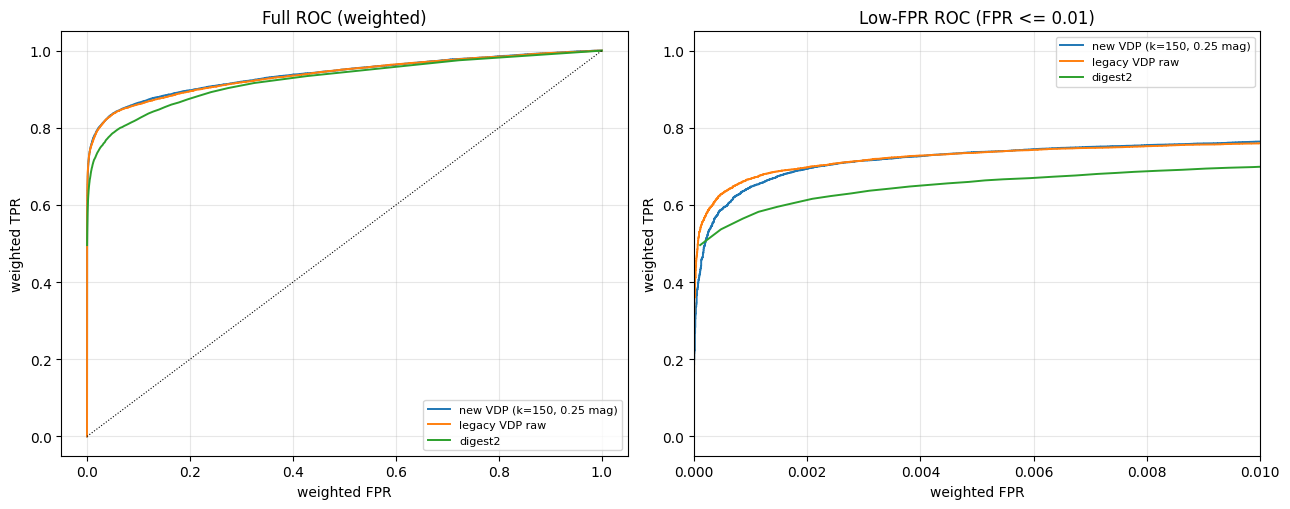

In [8]:
def roc_w(y,s,w):
    o=np.argsort(-s,kind="mergesort"); y,s,w=y[o],s[o],w[o]
    tp=np.cumsum(w*(y==1)); fp=np.cumsum(w*(y==0))
    keep=np.concatenate([np.diff(s)!=0,[True]])
    return fp[keep]/w[y==0].sum(), tp[keep]/w[y==1].sum()

cm = df[df.new_vdp_valid & df.legacy_vdp_valid & df.digest2_valid]
y = (cm.population=="NEO").to_numpy().astype(int); wv = cm.w_phys.to_numpy(float)
series = [("new VDP (k=150, 0.25 mag)","P_NEO_new"),
          ("legacy VDP raw","P_NEO_legacy_raw"),
          ("digest2","P_NEO_digest2")]
fig,ax=plt.subplots(1,2,figsize=(13,5.2))
for lab,col in series:
    f_,t_=roc_w(y,cm[col].to_numpy(float),wv)
    ax[0].plot(f_,t_,lw=1.4,label=lab); ax[1].plot(f_,t_,lw=1.4,label=lab)
ax[0].plot([0,1],[0,1],"k:",lw=.8)
ax[0].set_xlabel("weighted FPR"); ax[0].set_ylabel("weighted TPR"); ax[0].set_title("Full ROC (weighted)")
ax[1].set_xlim(0,0.01); ax[1].set_xlabel("weighted FPR"); ax[1].set_ylabel("weighted TPR")
ax[1].set_title("Low-FPR ROC (FPR <= 0.01)")
for a_ in ax: a_.legend(fontsize=8); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Completeness versus contamination (weighted)

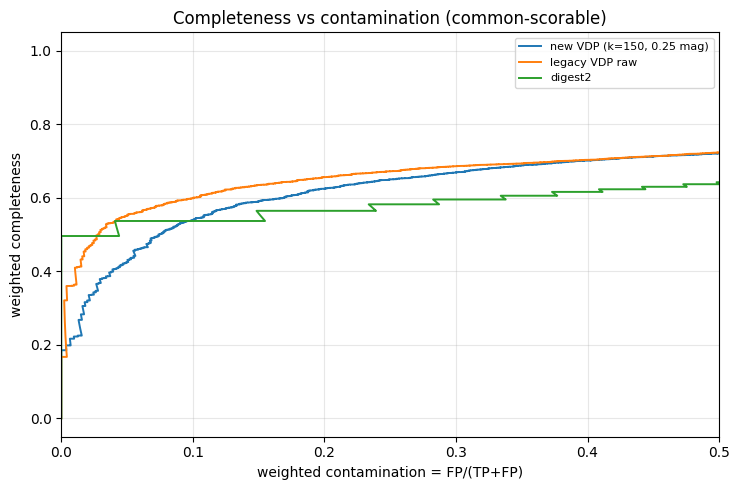

In [9]:
fig,ax=plt.subplots(figsize=(7.5,5))
for lab,col in series:
    s=cm[col].to_numpy(float); o=np.argsort(-s,kind="mergesort")
    yy,ww=y[o],wv[o]
    tp=np.cumsum(ww*(yy==1)); fp=np.cumsum(ww*(yy==0))
    comp=tp/ww[yy==1].sum(); cont=fp/np.maximum(tp+fp,1e-30)
    ax.plot(cont,comp,lw=1.4,label=lab)
ax.set_xlabel("weighted contamination = FP/(TP+FP)"); ax.set_ylabel("weighted completeness")
ax.set_xlim(0,0.5); ax.set_title("Completeness vs contamination (common-scorable)")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. Paired new-minus-legacy on identical rows

This is the internally valid comparison: same rows, same contaminants, same weights.

n 302,666   median -0.00005   mean -0.00577
p05 -0.00193   p95 +0.00046   new higher on 39.7% of rows


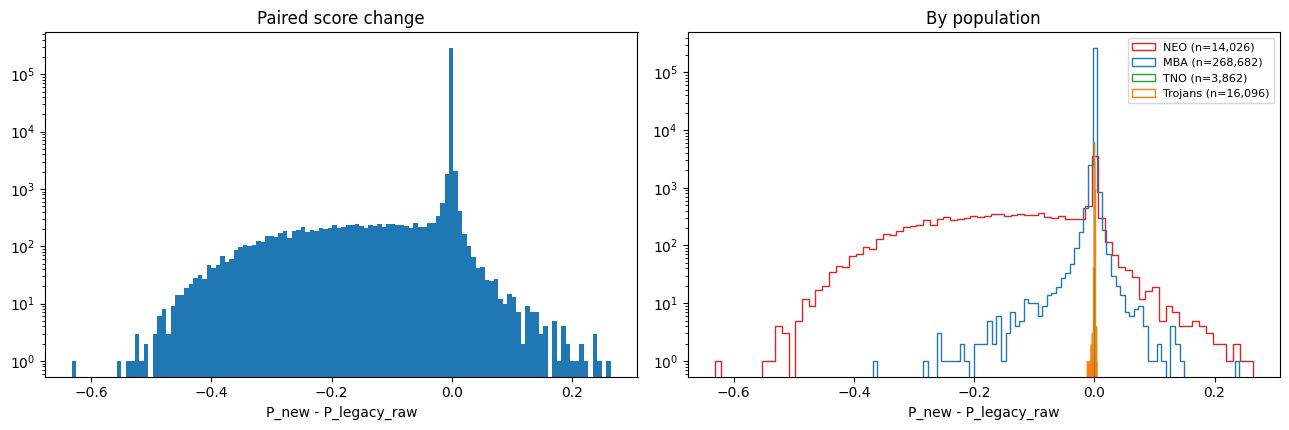

In [10]:
p = b["paired_new_minus_legacy_raw"]
print(f"n {p['n']:,}   median {p['median']:+.5f}   mean {p['mean']:+.5f}")
print(f"p05 {p['p05']:+.5f}   p95 {p['p95']:+.5f}   new higher on {100*p['frac_new_higher']:.1f}% of rows")
d = (cm.P_NEO_new - cm.P_NEO_legacy_raw).to_numpy(float)
fig,ax=plt.subplots(1,2,figsize=(13,4.4))
ax[0].hist(d,bins=120); ax[0].set_yscale("log")
ax[0].set_xlabel("P_new - P_legacy_raw"); ax[0].set_title("Paired score change")
for pop,c_ in zip(POPS,("C3","C0","C2","C1")):
    dd=(cm.P_NEO_new-cm.P_NEO_legacy_raw)[cm.population==pop]
    if len(dd): ax[1].hist(dd,bins=80,histtype="step",label=f"{pop} (n={len(dd):,})",color=c_)
ax[1].set_yscale("log"); ax[1].set_xlabel("P_new - P_legacy_raw"); ax[1].legend(fontsize=8)
ax[1].set_title("By population")
plt.tight_layout(); plt.show()

## 7. Legacy and digest2 on their own broader valid sets (View C)

**Not equivalent to View B.** These sets include rows the new VDP abstains on, which are the easier
majority, so the AUCs are higher and must not be compared directly with the View-B numbers.

In [11]:
c3 = pd.DataFrame(val["view_c_broader_valid_sets"]).T
print(c3.to_string())
print("\nView B (common-scorable, harder selected region):")
print(m[["classifier","AUC"]].to_string(index=False, float_format=lambda z:f"{z:.5f}"))
print("\nThe gap between View B and View C is a property of WHICH ROWS are scorable,")
print("not of classifier quality.")

                       n       auc  pauc_fpr01
legacy_vdp_raw  686100.0  0.965362    0.813313
digest2         688604.0  0.964488    0.726092

View B (common-scorable, harder selected region):
    classifier     AUC
       new_vdp 0.93814
legacy_vdp_raw 0.93695
legacy_vdp_cal 0.93695
       digest2 0.92474

The gap between View B and View C is a property of WHICH ROWS are scorable,
not of classifier quality.


## 8. Results by magnitude, sky direction and velocity

Scores always came from the 0.25-mag maps; these panels aggregate neighbouring bins only for
readable sample sizes. The full 0.25-mag table is saved regardless.

In [12]:
def auc_w(y,s,w):
    o=np.argsort(s,kind="mergesort"); y,s,w=y[o],s[o],w[o]
    P=w[y==1].sum(); N=w[y==0].sum()
    if P<=0 or N<=0: return np.nan
    below=np.concatenate([[0.0],np.cumsum(w*(y==0))[:-1]]); a=0.0; i=0
    while i<len(s):
        j=i
        while j+1<len(s) and s[j+1]==s[i]: j+=1
        a += w[i:j+1][y[i:j+1]==1].sum()*(below[i]+0.5*w[i:j+1][y[i:j+1]==0].sum()); i=j+1
    return a/(P*N)

cm2 = cm.copy()
cm2["Vgrp"] = pd.cut(cm2.mean_mag_V, [14,20,22,23,24,25])
cm2["absv"] = np.hypot(cm2.vlam, cm2.vbeta)
cm2["vgrp"] = pd.cut(cm2.absv, [0,0.25,0.5,1.0,2.0,5.0])
cm2["skygrp"] = pd.cut(cm2.beta_deg.abs(), [0,5,15,30,90])
for key,lab in (("Vgrp","apparent V"),("vgrp","|v| deg/day"),("skygrp","|ecliptic latitude| deg")):
    out=[]
    for g_,gg in cm2.groupby(key, observed=True):
        yy=(gg.population=="NEO").to_numpy().astype(int); ww=gg.w_phys.to_numpy(float)
        if yy.sum()<20 or (yy==0).sum()<20: continue
        out.append(dict(**{lab:str(g_)}, n=len(gg), n_neo=int(yy.sum()),
                        new=auc_w(yy,gg.P_NEO_new.to_numpy(float),ww),
                        legacy=auc_w(yy,gg.P_NEO_legacy_raw.to_numpy(float),ww),
                        digest2=auc_w(yy,gg.P_NEO_digest2.to_numpy(float),ww)))
    print(f"\nweighted AUC by {lab} (counts >= 20 per class):")
    print(pd.DataFrame(out).to_string(index=False, float_format=lambda z:f"{z:.4f}"))


weighted AUC by apparent V (counts >= 20 per class):
apparent V      n  n_neo    new  legacy  digest2
  (20, 22]  19801    552 0.9421  0.9411   0.9211
  (22, 23]  43532   1491 0.9422  0.9414   0.9246
  (23, 24]  85063   3404 0.9287  0.9272   0.9241
  (24, 25] 154270   8579 0.9375  0.9367   0.9392



weighted AUC by |v| deg/day (counts >= 20 per class):
|v| deg/day      n  n_neo    new  legacy  digest2
(0.0, 0.25] 121982   1392 0.7350  0.7243   0.7529
(0.25, 0.5] 161517   2391 0.8205  0.8197   0.7797
 (0.5, 1.0]  13752   4832 0.9408  0.9411   0.9306



weighted AUC by |ecliptic latitude| deg (counts >= 20 per class):
|ecliptic latitude| deg      n  n_neo    new  legacy  digest2
                 (0, 5] 145804   3694 0.9198  0.9171   0.8878
                (5, 15] 130053   5159 0.9240  0.9238   0.9072
               (15, 30]  25087   3920 0.9272  0.9253   0.9202
               (30, 90]   1722   1253 0.9210  0.9252   0.9316


### Fast-NEO subset

Fast objects are where a velocity-density prior should help most.

In [13]:
fast = cm2[cm2.absv > 1.0]
yy=(fast.population=="NEO").to_numpy().astype(int); ww=fast.w_phys.to_numpy(float)
print(f"fast rows {len(fast):,}  NEO {int(yy.sum()):,}")
if yy.sum()>=20 and (yy==0).sum()>=20:
    for lab,col in series:
        print(f"  {lab:28s} AUC {auc_w(yy,fast[col].to_numpy(float),ww):.5f}")
else:
    print("  insufficient counts in one class for a stable AUC")

fast rows 5,415  NEO 5,411
  insufficient counts in one class for a stable AUC


## 9. digest2 discrete operating points

digest2 emits integer scores, so only a finite set of thresholds is attainable.

attainable levels: 101

most populated levels:
0.0      204525
1.0      201078
2.0       56579
100.0     28916
3.0       27163
4.0       18271
5.0       13886
6.0       11581


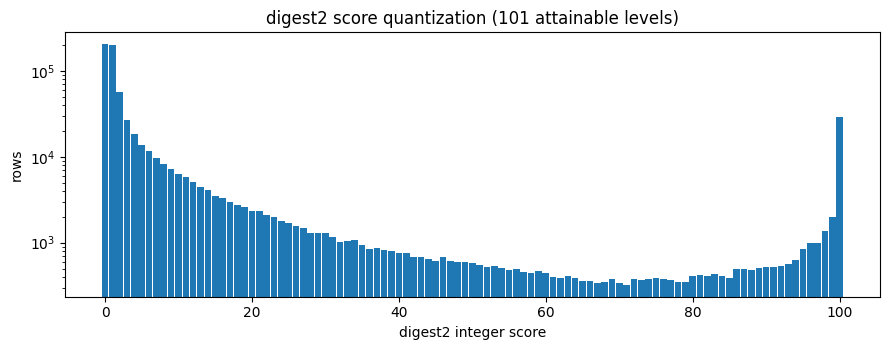

In [14]:
lv = val["digest2_operating_points"]
print(f"attainable levels: {lv['n_levels']}")
d2 = df.digest2_raw[df.digest2_valid].to_numpy(float)
vc = pd.Series(d2).value_counts().sort_index()
print("\nmost populated levels:"); print(vc.sort_values(ascending=False).head(8).to_string())
fig,ax=plt.subplots(figsize=(9,3.6))
ax.bar(vc.index, vc.values, width=.9); ax.set_yscale("log")
ax.set_xlabel("digest2 integer score"); ax.set_ylabel("rows")
ax.set_title(f"digest2 score quantization ({lv['n_levels']} attainable levels)")
plt.tight_layout(); plt.show()

## 10. Conclusions and limitations

Descriptive only. No threshold, no calibration and no model selection is derived from TEST2.

In [15]:
print("HEADLINE — common-scorable subset (302,666 rows, 43.95% of TEST2; NEO 14,026)")
print(m.to_string(index=False, float_format=lambda z:f"{z:.5f}"))
print()
print("1. On identical rows the new k=150 / 0.25-mag VDP and the legacy VDP are statistically")
print("   indistinguishable in weighted AUC (bootstrap CIs overlap substantially), and the legacy")
print("   map is BETTER at low FPR and at fixed contamination.")
print("2. digest2 is clearly below both VDP variants on this subset in AUC and pAUC.")
print("3. Legacy raw and calibrated give identical AUC/pAUC: Platt is monotonic, so ranking metrics")
print("   are invariant. Calibration changes probabilities, not ordering.")
print()
print("LIMITATIONS")
print(" * non-NEO parents are REUSED from the previously inspected TEST -> absolute contamination,")
print("   precision and FPR are not fresh out-of-sample quantities. Only NEO is fresh.")
print(" * four-density availability is 43.96% overall and ~28% for NEO, and is geometrically")
print("   selected; View B is NOT whole-population performance.")
print(" * legacy scores ~99% of rows partly because it uses 1-mag bins and treats missing densities")
print("   as zero (nan_to_num). That is a methodological difference, not new-VDP underperformance.")
print(" * no operating threshold is selected here; any best-F1 value would be descriptive only.")

HEADLINE — common-scorable subset (302,666 rows, 43.95% of TEST2; NEO 14,026)
    classifier     AUC  pAUC_FPR01   CI_lo   CI_hi  C_at_5pct  C_at_10pct
       new_vdp 0.93814     0.71476 0.93497 0.94095    0.42521     0.53907
legacy_vdp_raw 0.93695     0.72007 0.93346 0.94012    0.55062     0.59867
legacy_vdp_cal 0.93695     0.72007 0.93346 0.94012    0.55062     0.59867
       digest2 0.92474     0.63491 0.92139 0.92757    0.53686     0.53686

1. On identical rows the new k=150 / 0.25-mag VDP and the legacy VDP are statistically
   indistinguishable in weighted AUC (bootstrap CIs overlap substantially), and the legacy
   map is BETTER at low FPR and at fixed contamination.
2. digest2 is clearly below both VDP variants on this subset in AUC and pAUC.
3. Legacy raw and calibrated give identical AUC/pAUC: Platt is monotonic, so ranking metrics
   are invariant. Calibration changes probabilities, not ordering.

LIMITATIONS
 * non-NEO parents are REUSED from the previously inspected TEST -